## Ejercicio 1
Se tiene el siguiente modelo simplificado del funcionamiento de un sector de una fábrica de azúcar: Se tienen **N** tachos de cocimiento, cada uno de los cuales consume vapor de una determinada manera a lo largo del tiempo. El consumo total de vapor puede calcularse como la suma del consumo de vapor individual de cada tacho. El tiempo entre que empieza a consumir el primer tacho hasta que deja de consumir el último tacho es **tMAX** (llamado tiempo total del ciclo o *timespan*). Durante este tiempo, el consumo de vapor varía en el tiempo, consumiendo mayor energía mientras mayor sea esta variación. Este problema consiste en reducir la energía que se consume por la variación de vapor a lo largo del ciclo de cocimiento de la azúcar. A continuación se brindan detalles del modelado del problema:


Un tacho de cocimiento consume vapor durante un lapso de tiempo. El proceso arranca en el tiempo t0, y finaliza en t1 = t0+1 donde ya se consumió todo el vapor del tacho. Es decir, el proceso dura *una unidad de tiempo*. Este comportamiento se puede modelar como una parábola con las ramas hacia abajo, donde alcanza su máximo en t = 1, y está definida en el intervalo  t0 ≤ t ≤ t0+1, siendo nulo fuera de dicho intervalo. Es decir:

  * VaporTacho_i(t) = **0**, *si 0 ≤ t ≤ t0*
  * VaporTacho_i(t) = **1 - (2 * t0 - 2t + 1)^2**, *si t0 ≤ t ≤ t0+1*
  * VaporTacho_i(t) = **0**, *si t1 ≤ t ≤ tMAX*








In [394]:
import matplotlib.pyplot as plt

def VaporTacho_i(t, t0):
  return 1 - (2*t0-2*t + 1)**2 if t > t0 and t < t0+1 else 0

def VaporTotal(t_inicios, intervalo):
  return [sum([VaporTacho_i(t,t0) for t0 in t_inicios]) for t in intervalo]



Ahora suponga que la fábrica cuenta con una cantidad de tachos de cocimiento **N** que puede variar entre 5 y 20. Los tachos arrancan de manera
independiente entre ellos, y el vapor total puede ser calculado en cada instante de tiempo sumando el vapor producido por cada tacho. Es decir:

* VaporTotal(t) = SUM_i { VaporTacho_i(t) }

El objetivo del problema es diseñar un Algoritmo Genético que organice el cronograma de arranques (*Schedule*) de los tachos, de manera que:
* Todos los tachos deben completar su ciclo.
* Se estabilizce el consumo de vapor total (que no existan grandes variaciones de vapor durante todo el proceso). Es decir, se prefieren soluciones que produzcan un consumo de vapor "*constante*".
* Se prefieren soluciones que brinden un tiempo total de funcionamiento menor.
* Se debe evitar la convergencia hacia las soluciones triviales e incorrectas:
* El algoritmo debe ser general, funcionando para diferente cantidad de tachos **N**.
  * Donde el tiempo total es mínimo debido a que todos los tachos arrancan juntos.
  * Los tachos arrancan uno despues de otro (no se superponen).



La función fitness, entonces, deberá tener en cuenta las variaciones de vapor total en el tiempo, y el tiempo total del ciclo.


Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base a los objetivos del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidad de tachos presentes.

Funciones Necesarias para el Genetico


In [504]:

import random
import numpy as np

#seleccion
def sel_sus(F, cant_selectos, eps):
    """ Operador de seleccion stochastic universal sampling (SUS).
    Parametros:
    F: list. Lista de valores de fitness de cada individuo de la población.
    cant_selectos: int. Cantidad de individuos a seleccionar.
    eps: int. valor para normalizar el fitness (no lo estoy usando).
    S: list. Lista con las posiciones de los individuos seleccionados.
    """
    tot_fit = sum(F)
    lista_prob = [fit/tot_fit for fit in F]
    lista_prob_acum = [lista_prob[i] if i == 0 else lista_prob[i] + sum(lista_prob[:i]) for i in range(len(lista_prob))]
    random_num = random.uniform(0, (1 / cant_selectos))
    tiros = [random_num + i * (1 / cant_selectos) for i in range(cant_selectos)]
    # for tiro in tiros:
    #     if tiro <
    contador = 0
    i = 0
    j = 0
    S = []
    while contador < cant_selectos:
        if tiros[j] < lista_prob_acum[i]:
            S.append(i)
            contador += 1
            j += 1
        else:
            i +=1

    return S

## Crossover
def xov_cube(parent1, parent2):
    """
        parent1, parent2 listas de inicios de tiempos de los tachos de los padres

    """
    child1 = []
    child2 = []
    
    for p1, p2 in zip(parent1, parent2):
        rand = random.random()
        
        c1 = p1 + rand * (p2 - p1)
        c2 = p2 + rand * (p1 - p2)
        
        
        child1.append(c1)
        child2.append(c2)
        
    return child1, child2


def xov_cube2(P1, P2):
    """Operador Cube Crossover para Algoritmos Geneticos.
    Parametros:
    P1: list. Lista correspondiente a uno de los individuos padres a cruzar.
    P2: list. Lista correspondiente a uno de los individuos padres a cruzar.
    """
    size = min(len(P1), len(P2))
    R = [random.random() for _ in range(size)]  # un r_i distinto por gen

    C1 = [R[i] * (P2[i] - P1[i]) + P1[i] for i in range(size)]
    C2 = [R[i] * (P1[i] - P2[i]) + P2[i] for i in range(size)]

    #C1.sort()
    #C2.sort()

    return C1, C2
def xov_uniform(P1, P2):
    """Operador Uniform Crossover para Algoritmos Geneticos.
    Parametros:
    P1: list. Lista correspondiente a uno de los individuos padres a cruzar.
    P2: list. Lista correspondiente a uno de los individuos padres a cruzar.
    """

    Mask = [1 if (i % 2 == 0) else 0 for i in range(len(P1))]
    random.shuffle(Mask)

    C1 = [P1[i] if Mask[i] == 1 else P2[i] for i in range(len(P1))]
    C2 = [P2[i] if Mask[i] == 1 else P1[i] for i in range(len(P1))]

    return C1, C2

## Mutacion
def xov_single_point(P1, P2):

    P1_sorted = sorted(P1)
    P2_sorted = sorted(P2)

    cut_point = random.randint(1, len(P1_sorted) - 1)


    C1 = P1_sorted[:cut_point] + P2_sorted[cut_point:]
    C2 = P2_sorted[:cut_point] + P1_sorted[cut_point:]

    C1.sort()
    C2.sort()

    return C1, C2

def mut_step(P, Bounds, gen_act, probabilidad_direccion=0.5):
    """
    Step Mutation
    Parámetros
    P: list. Vector correspondiente a un individuo.
    bounds: list. Matriz que indica los valores maximo y minimo de cada coordenada.
    probabilidad_direccion: float. Probabilidad de que se mueva en la dirección indicada. En este caso preferimos que se mueva hacia el limite inferior de bounds
    """
    C = P.copy()
    cut = random.randint(0,len(P)-1)
    r = random.random()
    nuevo_valor =  r * C[cut] + (1-r) * Bounds[cut][random.random()>probabilidad_direccion]
    C[cut] = round(nuevo_valor,1)

    return C

def mut_step_non_uniform(P, Bounds, gen_act, b=0.3):
    gen_max = 12
    if gen_act >= gen_max:
        return P 
    C = P.copy()
    i = random.randint(0,len(P)-1)
    dir = 1 if random.randint(0, 1) > 0.5 else -1
    if dir == 1:
        max_chg = Bounds[i][1] - C[i]
    else:
        max_chg = C[i] - Bounds[i][0]
    try:
        x = (gen_act/gen_max)
        prob_x = (1-x) ** b
        step = random.random() * prob_x
    except:
        step = random.random() * 1
    C[i] = C[i] + dir * step * max_chg

    return C


Genetico


In [491]:
def geneticoTachos(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
                   cant_cruzados, cant_mutados, cant_elite, param_sel, f, \
                   variabilidad_weight, tiempo_weight, dist_max_weight,max_pico_weight, tachos, callback=None):
    """
    Algoritmo Genetico Simple
    Parametros:
    - Pop: list. poblacion inicial (lista de listas).
    - cant_generac: int. Cantidad de iteraciones del algoritmo. Usamos cantidad de generaciones sin mejora
    - Bounds: list: Matriz que indica los valores max y min de cada variable.
    - Enteras: list. Vector booleano que indica si las coordenadas son enteras.
    - cant_cruzados: int. Cantidad de individuos que seran cruzados.
    - cant_mutados: int. Cantidad de soluciones a las cuales se le aplicara
      mutacion.
    - cant_elite: int. Numero de mejores soluciones que pasan a la siguiente
      generacion sin cambio alguno.
    - param_sel: float. Parametro usado en la seleccion, por ejemplo el peso que
      se le asigna a la solucion menos probable en el calculo de la probabilidad
      para ruleta. En caso de usar torneo, este es el tamano del torneo.
    - f: function. Funcion de evaluacion. Debe recibir como parametro un vector
      solucion y devolver un numero real.
    - intersections_weight: Un peso en distancia para las intersecciones en el recorrido
    - measure_intersections: Si tengo en cuenta la penalidad por usar intersecciones
    - callback: function. Funcion que se ejecuta una vez en cada iteracion (para
      mostrar resultados parciales). Usar None para deshabilitarla.
    Salida
    - soluc: list. Vector solucion que obtuvo fitness mas alto.
    - solF: float. Valor de evaluacion de la mejor solucion.
    - Pop: list. Poblacion final.
    - Fit: list. Fitness de cada individuo de la poblacion final.
    - traceBest: list. Vector con los mejores valores de fitness obtenidos en
      cada generacion. Se puede utilizar para determinar si el algoritmo
      llego a crowding.
    - traceAvg: list. Vector con los valores promedio de fitness
      obtenidos en cada generacion.
    """
    #inicializacion
    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    mejor = 0
    gen = 0
    cant_intentos_malos = 0
    #mejor conserva el valor de la mejor solucion
    #cant_intentos malos va acumulando y sera mi condicion de parada.

    #verifico los parametros de entrada
    if cant_soluc < 2:
        print('La Poblacion debe tener al menos dos individuos.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    cant_variables = len(Pop[0])
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print('El tamano de la matriz Bounds es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if len(Enteras) != cant_variables:
        print('El tamano del vector Enteras es incorrecto.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print('La cantidad de cruzados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print('La cantidad de mutados debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite >= cant_soluc:
        print('El tamano de la elite debe ser menor que el tamano de la poblacion.')
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    #inicializo variables para reducir tiempo de calculo
    cb_param = None
    p = [i for i in range(cant_soluc)]

    #realizo las evaluaciones de la poblacion inicial.
    for k in range(cant_soluc):
        #Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
        #Fit[k] = f(Pop[k],  variabilidad_weight, picos_weight, dist_max_weight, intervalo)
        Pop[k] = Pop[k]
        Fit[k] = f(Pop[k], variabilidad_weight, tiempo_weight, dist_max_weight, max_pico_weight)
    #if callback != None:
     #   cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)
    #obtengo el orden de los individuos
    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    mejor = Fit[p_orden[0]]


    while(True):
        # print(f'Generacion: {gen}')
        #selecciono la elite de la generacion actual (una copia)
        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]

        #seleccion
        p_sel = sel(Fit, cant_soluc, param_sel)
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]

        #cruzamiento
        random.shuffle(p)
        for k in range(0, cant_cruzados, 2):
            C1, C2 = xover(Pop[p[k]], Pop[p[k+1]])
            Pop[p[k]] = [xi for xi in C1]
            Pop[p[k+1]] = [xi for xi in C2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        #mutacion
        #random.shuffle(p)
        for k in range(cant_soluc-cant_mutados, cant_soluc):
            C = mut(Pop[p[k]], Bounds, gen)
            Pop[p[k]] = [xi for xi in C]
            Fit[p[k]] = None

          #mutacion2
        # random.shuffle(p)
        # for k in range(cant_mutados2):
        #     C2 = mut2(Pop[p[k]], Bounds)
        #     Pop[p[k]] = [xi for xi in C2]
        #     Fit[p[k]] = None


      

        #realizo las evaluaciones de la nueva generacion
        for k in range(cant_soluc):
            if Fit[k] == None:
                Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
                Fit[k] = f(Pop[k], variabilidad_weight, tiempo_weight, dist_max_weight, max_pico_weight)

        #obtengo el orden de los individuos
        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)

          #inserto la elite en la nueva poblacion en el peor individuo
        #random.shuffle(p)
        for k in range(cant_elite):
            Pop[p_orden[-(k+1)]] = Elite[k]
            Fit[p_orden[-(k+1)]] = Elite_Fit[k]
        
        #obtengo el orden de los individuos
        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
        
        #datos estadisticos
        traceBest.append(Fit[p_orden[0]])
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        if mejor >= Fit[p_orden[0]]:
          cant_intentos_malos += 1
        else:
          cant_intentos_malos = 0
          mejor = Fit[p_orden[0]]

        if cant_intentos_malos >= cant_generac:
          solF = Fit[p_orden[0]]
          sol = Pop[p_orden[0]]
          return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

        gen += 1



        #funcion para graficar, mostrar, etc.
        # if callback != None:
        #     cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

    #busco la mejor solucion obtenida
    # solF = Fit[p_orden[0]]
    # sol = Pop[p_orden[0]]
    # #graficar_generacion(Pop)

    # return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

Funciones para graficar


In [490]:
def graficarEvolucionFitness(best, mean):
    """Método para graficar la evolucion del fitness con las iteraciones.
    Parametros
    best, mean : list. Lista con los valores de evaluación de la mejor y peor solución.
    """
    fig = plt.figure()
    ax = plt.axes()
    x = range(len(best))
    plt.plot(x, best, label='Mejor solución')
    plt.plot(x, mean, label='Promedio poblacion')
    plt.title('Valores de Evaluación')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.grid()
    plt.legend()
    plt.show()
    
def graficarResultadosTachos(solucion, tachos, intervalo):

    plt.figure()

    for i in range(len(solucion)):
        vt = [VaporTacho_i(t,solucion[i]) for t in intervalo]
        plt.plot(intervalo, vt, label=f'Tacho {i}')

    vtotal = VaporTotal(solucion, intervalo)
    #equilibrio = Promedio(vtotal, intervalo, solucion)
    #picos = Picos(vtotal, intervalo)
    #variabilidad = Variabilidad(vtotal, intervalo, solucion)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    #plt.figure()
    plt.plot(intervalo, vtotal, label='Total', color='black')
    #for i in range(len(picos)):
     #   if picos[i] > 0:
      #      plt.plot(intervalo[i], picos[i], marker='+', color='red', linestyle='')
    #plt.axhline(equilibrio, color='blue', linestyle='--', linewidth=1.2,
     #           label=f'Equilibrio ({equilibrio:.2f})')
    # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    # plt.figure()
    # #plt.plot(intervalo, variabilidad, label='Varianza')
    # plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

Inicializacion de individuos

In [399]:
import random
def init_pop(cant_individuos, tachos):
    return [[round((random.random() * (tachos-1)),1) for i in range(tachos)] for j in range(cant_individuos)]
    #return[[i for i in range(tachos)]for j in range(cant_individuos)]
inicializacion = init_pop(10,20)
print(inicializacion)

[[7.1, 15.1, 18.5, 1.2, 7.2, 1.6, 10.1, 18.4, 11.6, 13.7, 15.5, 4.7, 7.2, 9.9, 10.2, 15.1, 13.7, 14.8, 14.8, 16.5], [10.1, 11.4, 9.9, 6.0, 11.5, 1.5, 4.9, 0.2, 7.0, 6.9, 11.4, 14.6, 1.2, 0.2, 16.0, 4.1, 5.3, 11.9, 0.8, 9.7], [13.5, 11.0, 8.9, 14.9, 14.4, 15.4, 17.9, 2.4, 18.5, 7.6, 17.0, 6.7, 3.4, 2.1, 9.6, 12.1, 13.9, 0.8, 4.2, 5.9], [0.0, 3.9, 9.6, 3.3, 11.0, 8.8, 5.4, 0.8, 0.1, 17.7, 13.4, 3.4, 16.3, 2.2, 16.8, 13.7, 15.1, 18.1, 17.0, 14.6], [17.3, 14.2, 12.1, 2.5, 0.5, 7.8, 6.6, 13.9, 18.7, 18.7, 0.7, 9.3, 18.9, 7.8, 11.3, 15.8, 0.1, 2.8, 14.9, 0.5], [12.2, 15.9, 13.1, 15.7, 6.0, 7.8, 2.8, 14.7, 7.0, 1.9, 7.8, 7.7, 10.4, 0.5, 5.4, 15.1, 14.7, 2.8, 16.2, 16.2], [4.9, 0.5, 4.0, 15.5, 17.1, 2.2, 0.9, 3.8, 6.9, 14.6, 0.6, 0.1, 17.2, 11.2, 16.0, 2.8, 12.7, 10.9, 15.6, 0.6], [14.3, 10.7, 10.4, 10.7, 8.7, 15.5, 3.4, 8.6, 1.9, 4.4, 0.8, 4.6, 11.2, 7.8, 18.7, 7.0, 9.5, 17.6, 14.0, 8.5], [3.0, 12.6, 6.4, 18.2, 9.0, 11.2, 10.6, 18.7, 14.9, 17.4, 9.2, 18.2, 0.0, 2.6, 9.0, 6.7, 4.9, 8.5, 18.0, 

Fitness


In [510]:
import numpy as np

def Fitness(t_inicios, variabilidad_weight, tiempo_weight, dist_max_weight,max_pico_weight):
    t_min = min(t_inicios)
    t_max= max(t_inicios) +1
    intervalo = np.linspace(t_min+0.5,t_max-0.5,200)
    vapor_tachos = VaporTotal(t_inicios,intervalo)
    
    # fitness = np.std(vapor_tachos)/np.mean(vapor_tachos) + tiempo *3
    std = np.std(vapor_tachos)
    mean = np.mean(vapor_tachos)
    tiempo = tiempo_total(t_inicios)
    t_tot_posible = len(t_inicios)
    max_vapor = max(vapor_tachos)
    min_vapor = min(vapor_tachos)
    # print(f'STD/mean: {std / mean}')
    # #print(f'MEAN {mean}')
    # print(f'Tiempo: {tiempo / t_tot_posible}')
    # print(f'Max - Min {(max_vapor-min_vapor)}')
    fitness = (std / mean) * variabilidad_weight + (tiempo / t_tot_posible)* tiempo_weight  +   ((max_vapor-min_vapor)/ len(t_inicios)) * dist_max_weight + (max_vapor / len(t_inicios)) * max_pico_weight
    return -(fitness * 1000)
    #variacion = variacion_total(vapor_tachos)
    
    # #fitness = -variacion - tiempo *5- max(vapor_tachos) *3
    # fitness = - tiempo *500
   # return - np.std(vapor_tachos) - tiempo 
    #return -tiempo *5 - variacion **2 - max(vapor_tachos) *3

    
def variacion_total(vapor_tachos):
    return np.sum(np.abs(np.diff(vapor_tachos))) 

def tiempo_total(t_inicios):
    return max(t_inicios) - min(t_inicios) + 1
def primera_derivada(y_anterior, y_posterior, delta_x):
   return (y_posterior-y_anterior) / (2 * delta_x)

 

Implementacion

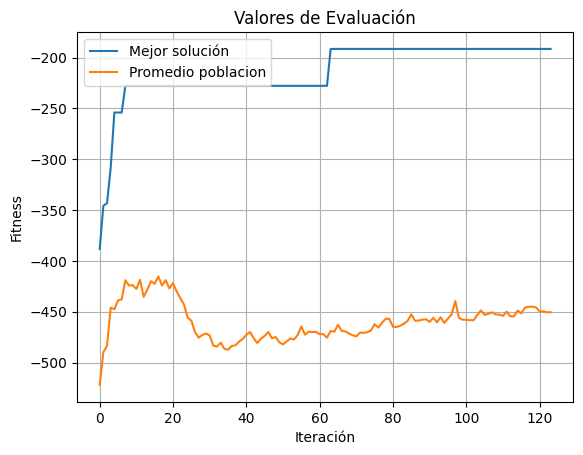

El schedule de solucion es [7.185947120742056, 7.484117384639121, 7.503447877227617, 7.911303510079841, 8.287364247546144, 8.289623051091034, 8.451666551539379, 8.964881181557955, 8.976073653857384, 9.306355167742645, 9.387473254423522, 9.850552444474326, 9.923020557806677, 9.932199157923522, 10.01261001385341, 10.295921137873897, 10.664641603014077, 10.684904079916777, 10.940137345019798, 11.016036858862739]
El fitness de la solucion es -191.40352798157596


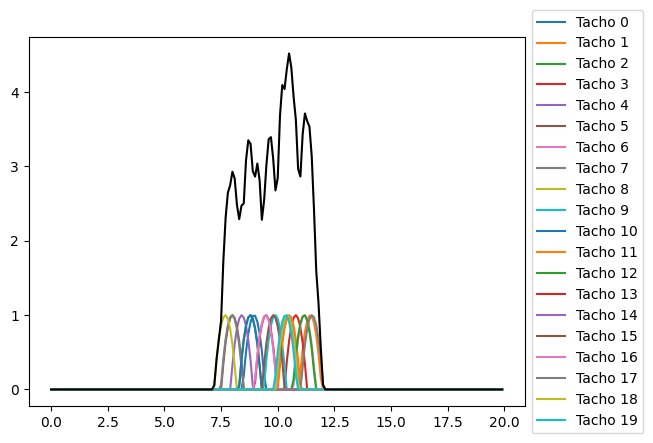

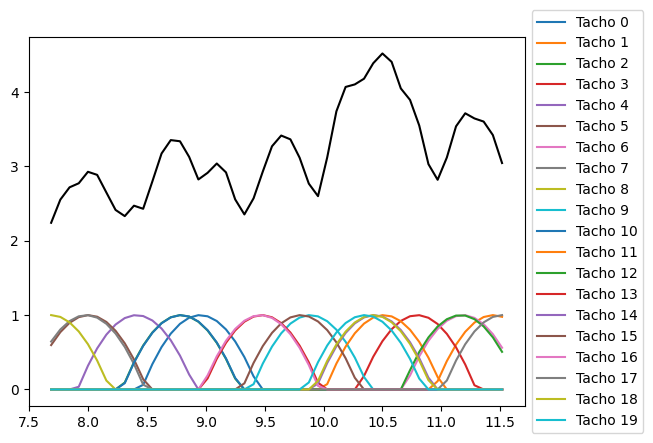

In [517]:
import random
import math

tachos = 20
Bounds = [[0, tachos-1] for i in range(tachos)]
Enteras = [False] * (tachos)
f = Fitness
cant_individuos = 60
cant_generac = 60
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = xov_cube
cant_cruzados = round(0.7 * cant_individuos)
mut = mut_step_non_uniform
cant_mutados = round(0.3 * cant_individuos)
callback = None
Variabilidad_weight = 0.25
Tiempo_weight =0.25
DistMax_weight = 0.25
max_pico_weight = 0.25
Pop = init_pop(cant_individuos, tachos)

sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
    geneticoTachos(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
        cant_cruzados, cant_mutados, cant_elite, eps, f, Variabilidad_weight, \
        Tiempo_weight, DistMax_weight,max_pico_weight,  tachos, callback)

graficarEvolucionFitness(traceBest, traceAvg)
print(f'El schedule de solucion es {sorted(sol)}')
print(f'El fitness de la solucion es {Fitness(sol, Variabilidad_weight, Tiempo_weight, DistMax_weight, max_pico_weight)}')
graficarResultadosTachos(sol, tachos, [x/10 for x in range(tachos * 10)])
graficarResultadosTachos(sol, tachos, np.linspace(min(sol)+0.5,max(sol)+0.5))